# Schedule Generator

---

*Runs After*: `fov.ipynb`, `skygrid.ipynb`, `skyblocks.ipynb`
*Runs Before*: None

This notebook converts the spatial scheduling blocks produced by `skyblocks.ipynb` into a concrete UVEX survey timeline.

The scheduler operates on **sky blocks**, rather than individual fields. Each block is a spatially contiguous collection of dwells sized so that the entire block (including the required slews) can be completed within a single interval between ground contacts. The block construction is handled upstream by `skyblocks.ipynb`; this notebook is responsible for deciding **when each block is observed** and **in what order its fields are visited**.

The scheduling problem is therefore split into two levels:

1. **Block-to-slot assignment** — determine which sky block should be observed during each interval between ground contacts.
2. **Within-block sequencing** — once a block has been assigned to a slot, determine the slew-minimizing order in which to visit its fields.

This separation keeps the global scheduling problem tractable while still accounting for observability, sky background, cadence requirements, and spacecraft slew overhead.

### Scheduling Procedure

The notebook proceeds as follows:

1. **Load the survey geometry.**
   Load the instrument FOV and the field/block table generated by the upstream notebooks. Each field already has a `BLOCK_ID` and an `EXPECTED_VISITS` value describing how often its block should be scheduled during the prime mission.

2. **Construct the ground-contact timeline.**
   UVEX must periodically return to a prescribed downlink orientation. These ground contacts divide the mission into fixed scheduling slots of duration `TIME_BETWEEN_GROUND_CONTACT`. One sky-block visit is assigned to each usable slot.

3. **Check cadence demand against available mission time.**
   Before attempting the optimization, compare the total number of requested block visits with the number of available scheduling slots. Because each block visit occupies one ground-contact interval by construction, this provides a simple diagnostic for whether the requested survey cadence is achievable within `PRIME_MISSION_DURATION`.

    <div class="alert warning">
      <strong>Warning!</strong> The scheduler will still run even if the requested cadence exceeds the available prime mission time. Please check the output of this diagnostic to ensure that the resulting schedule is acceptable.
    </div>

4. **Determine block observability.**
   Evaluate the mission visibility constraints for every field at every scheduling slot. A block is considered observable only when **all of its constituent fields** satisfy the mission constraints at that slot.

5. **Compute block-slot weights.**
   For every observable `(block, slot)` pair, estimate the total FUV exposure time required to reach `SNR_TARGET` for the fields in that block under the expected sky background. These values provide the cost used by the global scheduling optimization: lower-background observing opportunities are preferred.

6. **Assign blocks to scheduling slots.**
   Represent each required visit to each block as a node in a weighted bipartite graph and match those visits to available scheduling slots. The matching respects block observability and preferentially assigns blocks to slots with lower exposure-time cost.

7. **Optimize the observing order within each block.**
   Once a block has been assigned to a specific slot, its observing time—and therefore its nominal spacecraft roll—is known. The downlink pointing and all fields in the block are then treated as a small traveling-salesperson problem (TSP), with pairwise slew times as edge weights. Solving this TSP determines the field ordering that minimizes the total slew time for that block visit.

8. **Assemble the mission timeline.**
   The optimized block visits are stitched together chronologically, including downlinks, slews, and science dwells. The resulting schedule is checked for timing consistency, annotated with slew angles and total time spent in each activity, and written to `initial-survey.ecsv`.

9. **Optionally visualize the survey.**
   The final section can render an animation showing how the requested visit depth accumulates across the sky over the course of the mission.

---

## Notes

The sections below discuss details of the scheduling model that are useful for understanding some of the less obvious constraints and design choices. They are not required for a first-pass execution of the pipeline.

<details>
<summary><b>Why schedule blocks instead of individual fields?</b></summary>

<br>

The scheduler intentionally does not optimize the complete sequence of individual UVEX fields over the full mission. Such a problem would be extremely large and would mix several different optimization scales.

Instead, `skyblocks.ipynb` first groups nearby fields into compact scheduling blocks. A block is small enough to fit within one interval between ground contacts and is constructed so that fields with different cadence requirements do not normally share the same block.

This allows the scheduling problem to be decomposed naturally:

* the **global optimization** chooses when each block is observed;
* the **local optimization** chooses the best slew path through the fields within that block.

The required periodic downlink effectively resets the spacecraft trajectory every `TIME_BETWEEN_GROUND_CONTACT`, so there is relatively little benefit in optimizing slew paths across block boundaries. This makes the block a natural independent unit for slew optimization.

</details>

<details>
<summary><b>Block observability</b></summary>

<br>

A scheduling block is treated as an indivisible observing unit. Consequently, a block is considered available during a scheduling slot only if **every field in the block** satisfies the UVEX mission constraints at the representative time for that slot.

This is more restrictive than testing the fields independently, but it guarantees that a block selected by the matching step can actually be executed in full without violating the visibility constraints partway through the sequence.

</details>

<details>
<summary><b>Background weighting</b></summary>

<br>

Observability determines whether a `(block, slot)` assignment is allowed; the exposure-time weight determines which allowed assignments are preferred.

For each field and scheduling slot, the notebook estimates the FUV exposure time required to reach `SNR_TARGET` for a reference source under the predicted sky background. The field exposure times are summed across each block, producing a block-slot cost.

The bipartite matching therefore preferentially places observations in lower-background portions of the mission while still respecting visibility and the requested number of visits to each block.

This weight does **not** represent slew cost. Slew optimization is performed separately after the block has been assigned a time.

</details>

<details>
<summary><b>Nominal roll and slew distance</b></summary>

<br>

For a spacecraft, angular separation between two telescope boresights is not generally equal to the physical rotation required to move between the corresponding attitudes.

UVEX's nominal roll depends on both the target direction and the Sun position. Consequently, two nearby fields can require significantly different spacecraft orientations even when their boresights are separated by only a small angle.

This is why the scheduler uses the full nominal attitudes when computing slew times inside a scheduled block. Importantly, the nominal roll cannot be known completely during the initial construction of the sky blocks because it depends on the time at which the block is ultimately observed.

The workflow therefore separates the two stages:

1. `skyblocks.ipynb` constructs spatially compact blocks without knowing their final observing times.
2. This notebook assigns each block to a time slot.
3. Once that time is known, the nominal rolls can be evaluated and the true slew-minimizing path through the block can be calculated.


</details>

## Settings / Configuration


In [58]:
%xmode minimal

Exception reporting mode: Minimal


In [59]:
# ========================================= #
# Manage Warnings                           #
# ========================================= #
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", ".*dubious year.*")
warnings.filterwarnings(
    "ignore", "Tried to get polar motions for times after IERS data is valid.*"
)

In [60]:
# ========================================= #
# Imports                                   #
# ========================================= #
from pathlib import Path

import networkx as nx
import numpy as np
import synphot
from astropy import units as u
from astropy.coordinates import SkyCoord, UnitSphericalRepresentation
from astropy.table import QTable, vstack
from astropy.time import Time
from astropy.utils.masked import Masked, combine_masks
from ligo.skymap import plot  # noqa: F401
from m4opt import fov  # noqa: F401 (used only inside a %%skipif-gated cell)
from m4opt.dynamics import EigenAxisSlew, nominal_roll
from m4opt.fov._core import (
    circle_to_polygon,  # noqa: F401 (used only inside a %%skipif-gated cell)
)
from m4opt.missions import uvex as mission
from m4opt.missions import uvex_downlink_orientation
from m4opt.synphot import observing
from m4opt.utils.optimization import solve_tsp
from matplotlib import pyplot as plt
from matplotlib import ticker as mtick
from matplotlib.animation import (
    FuncAnimation,  # noqa: F401 (used only inside a %%skipif-gated cell)
)
from matplotlib.collections import (
    PatchCollection,  # noqa: F401 (used only inside a %%skipif-gated cell)
)
from regions import (
    CircleSkyRegion,  # noqa: F401 (used only inside a %%skipif-gated cell)
    PointSkyRegion,  # noqa: F401 (used only inside a %%skipif-gated cell)
    Regions,
)
from tqdm.auto import tqdm

In [61]:
# ========================================= #
# ``%%skipif`` cell magic                   #
# ========================================= #
# Lets a cell be gated behind a boolean setting (e.g. ``SAVE_SCHEDULE_ANIMATION``) without
# commenting it out. The expression on the magic line is evaluated against the notebook
# namespace; if it is True, the rest of the cell is not executed. Usage: ``%%skipif <expr>`` as
# the first line of a cell.
from IPython import get_ipython
from IPython.core.magic import register_cell_magic


@register_cell_magic
def skipif(line, cell):
    # Evaluate the expression given to the magic command
    if eval(line, get_ipython().user_ns):
        print(f"Cell skipped: condition '{line}' is True.")
        return
    # If False, execute the cell code normally
    get_ipython().run_cell(cell)

### Configuration Settings

A number of configuration settings are available in this notebook. Please configure the options below to your liking. The default settings are recommended for most users.

In [62]:
# ========================================= #
# Settings and Configuration                #
# ========================================= #

# --- CORE SETTINGS --- #
# OUTPUT_PATH: Directory shared with ``fov.ipynb``, ``skygrid.ipynb``, and ``skyblocks.ipynb``.
#              This notebook reads their outputs from here and writes the final schedule (and any
#              plots/animation) back into it.
OUTPUT_PATH = Path("../preliminary_survey")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --- FOV SETTINGS --- #
# Paths to the DS9 region files written by ``fov.ipynb``. If ``None``, they are looked up in
# ``OUTPUT_PATH`` (i.e. wherever ``fov.ipynb`` wrote them).
MISSION_FOV_PATH = None
INSCRIBED_CIRCLE_FOV_PATH = None

# --- FIELDS / BLOCKS SETTINGS --- #
# Paths to the per-field and per-block tables written by ``skyblocks.ipynb``. If ``None``, they
# are looked up in ``OUTPUT_PATH`` (i.e. wherever ``skyblocks.ipynb`` wrote them).
FIELDS_FILE_PATH = None
BLOCKS_FILE_PATH = None

# --- UVEX MISSION SETTINGS --- #
TIME_BETWEEN_GROUND_CONTACT = 6 * u.hour
DOWNLINK_DURATION = 30 * u.minute
DWELL_DURATION = 900 * u.second
PRIME_MISSION_DURATION = 2 * u.year
MISSION_START_TIME = Time("2030-01-01")

# --- SCHEDULING SETTINGS --- #
# SNR_TARGET: Target signal-to-noise ratio used to estimate the FUV exposure time that drives the
#             per-slot background weighting in the matching step below.
SNR_TARGET = 5

# PLAN_BLOCK_TSP_TIMELIMIT: Wall-clock cap on each per-block TSP solve in "Sequence Each Block via
#     TSP" below. solve_tsp() is an *exact* MILP (Miller-Tucker-Zemlin formulation) via CPLEX, and
#     m4opt.milp.Model's own default timelimit is unbounded -- so without this, a hard instance
#     solves forever instead of just slowly. The Magellanic Clouds block (block 0) is one: its 20
#     fields are the tightest angular cluster in the survey, which makes the TSP's distance matrix
#     have many near-equal entries -- a weak LP relaxation bound, and CPLEX has to explore a huge
#     branch-and-bound tree to *prove* optimality even though it finds a near-optimal tour almost
#     immediately. A swept test across the full 3-year mission showed this block pegs a 15s cap at
#     every season while an ordinary block stays under 0.1s -- see the padding/investigation notes
#     for skyblocks.ipynb.
#     Passing a finite ``timelimit`` to ``m4opt.milp.Model`` also automatically switches its CPLEX
#     "MIP emphasis" from proving optimality to finding good feasible solutions (see
#     ``m4opt/milp.py``, ``Model.__init__``) -- so there is nothing separate to configure for that;
#     setting this one value gets both behaviors.
PLAN_BLOCK_TSP_TIMELIMIT = 20 * u.s

# --- DIAGNOSTIC PLOT SETTINGS --- #
SAVE_BLOCK_AVAILABILITY_PLOT = True

# --- ANIMATION SETTINGS --- #
# Controls for the optional survey-schedule animation generated at the end of this notebook.
# Animating the full PRIME_MISSION_DURATION timeline is expensive, so this is off by default --
# set SAVE_SCHEDULE_ANIMATION = True and tune ANIMATION_N_FRAMES to render it.
SAVE_SCHEDULE_ANIMATION = True
ANIMATION_N_FRAMES = 200
ANIMATION_DPI = 150
ANIMATION_INTERVAL = 300  # milliseconds between frames
# ANIMATION_REGION_FILES: DS9 region files whose boundaries are drawn as orange outlines on top
# of the animation, so LMLZ Wide/Deep and the Magellanic Clouds are visible as sky regions rather
# than only inferable from field color. Same files (and same relative paths) skyblocks.ipynb
# reads for LMLZ_WIDE_REGION_FILE/LMLZ_DEEP_REGION_FILE/MC_REGION_FILE.
ANIMATION_REGION_FILES = [
    Path("../survey-footprints/lmlz-wide.ds9"),
    Path("../survey-footprints/lmlz-deep.ds9"),
    Path("../survey-footprints/magellanic-clouds.ds9"),
]

## Field of View and Blocks

Load the FOV region files produced by ``fov.ipynb`` and the fields/blocks table produced by
``skyblocks.ipynb``. Two FOV shapes are loaded for two different purposes: `MISSION_FOV` is the
true chip mosaic, used wherever the actual detector footprint matters (e.g. plotting), while
`INSCRIBED_CIRCLE_FOV` is a single circle inscribed in that mosaic. Because a circle looks the
same at every roll angle, anything inside it is guaranteed to fall within the true mosaic
footprint no matter how the spacecraft is oriented -- which is why the sky grid was built around
this shape, and why it is what the coverage animation at the end of this notebook uses.

In [63]:
# ========================================= #
# Load FOV Files and the Fields/Blocks Tables #
# ========================================= #
MISSION_FOV_PATH = (
    OUTPUT_PATH / "chips.ds9" if MISSION_FOV_PATH is None else Path(MISSION_FOV_PATH)
)
INSCRIBED_CIRCLE_FOV_PATH = (
    OUTPUT_PATH / "inscribed-circle.ds9"
    if INSCRIBED_CIRCLE_FOV_PATH is None
    else Path(INSCRIBED_CIRCLE_FOV_PATH)
)
FIELDS_FILE_PATH = (
    OUTPUT_PATH / "fields.ecsv" if FIELDS_FILE_PATH is None else Path(FIELDS_FILE_PATH)
)
BLOCKS_FILE_PATH = (
    OUTPUT_PATH / "blocks.ecsv" if BLOCKS_FILE_PATH is None else Path(BLOCKS_FILE_PATH)
)

for _path, _source_notebook in (
    (MISSION_FOV_PATH, "fov.ipynb"),
    (INSCRIBED_CIRCLE_FOV_PATH, "fov.ipynb"),
    (FIELDS_FILE_PATH, "skyblocks.ipynb"),
    (BLOCKS_FILE_PATH, "skyblocks.ipynb"),
):
    if not _path.exists():
        raise FileNotFoundError(
            f"File not found at {_path}. Run {_source_notebook} first (writing to the same OUTPUT_PATH) to generate it."
        )

MISSION_FOV = Regions.read(str(MISSION_FOV_PATH))
(INSCRIBED_CIRCLE_FOV,) = Regions.read(str(INSCRIBED_CIRCLE_FOV_PATH))

# One row per field: block membership, region flags, and each field's own EXPECTED_VISITS/CATEGORY.
FIELDS = QTable.read(FIELDS_FILE_PATH)

# One row per block: field-type composition, resolved cadence, and padding-contamination
# diagnostics (IS_MIXED, EXCESS_FIELD_VISITS) -- see skyblocks.ipynb.
BLOCKS = QTable.read(BLOCKS_FILE_PATH)

# GRID_FIELDS repeats each field's row BLOCK_DWELLS times (1 for an ordinary block, more for
# a field-mode block like LMLZ Deep -- see "Field-Mode Blocks" in skyblocks.ipynb). This is
# the table actually used to build the observability/exposure-weight grids and the target
# list below, so that a field-mode block's repeated same-field dwells are counted (and later
# scheduled) as separate targets, while FIELDS itself stays one row per physical field for
# anything (like the animation at the end of this notebook) that wants exactly one patch per
# field on the sky.
GRID_FIELDS = FIELDS[np.repeat(np.arange(len(FIELDS)), FIELDS["BLOCK_DWELLS"])]
BLOCK_IDS = GRID_FIELDS["BLOCK_ID"]

## Downlink Schedule

In every ``TIME_BETWEEN_GROUND_CONTACT`` observing window, the telescope must return to its
downlinking orientation for ``DOWNLINK_DURATION`` so the high-gain antenna can face the ground
station. That orientation is fixed by spacecraft geometry alone (see
`m4opt.missions.uvex_downlink_orientation` for the full derivation) and does not depend on
anything decided later in this notebook, so the entire downlink timeline can be generated up
front, before any block has been scheduled.

In [64]:
# ========================================= #
# Generate Downlink Times and Orientations  #
# ========================================= #
DOWNLINK_TIMES = (
    MISSION_START_TIME
    + np.arange(
        0,
        PRIME_MISSION_DURATION.to_value(u.day),
        TIME_BETWEEN_GROUND_CONTACT.to_value(u.day),
    )
    * u.day
)

DOWNLINK_TARGET_COORDS, DOWNLINK_ROLLS = uvex_downlink_orientation(DOWNLINK_TIMES)
DOWNLINK_TARGET_COORDS = DOWNLINK_TARGET_COORDS.icrs
DOWNLINK_OBSERVER_LOCATIONS = mission.observer_location(DOWNLINK_TIMES)

DOWNLINK_TABLE = QTable(
    {
        "start_time": DOWNLINK_TIMES,
        "target_coord": SkyCoord(
            DOWNLINK_TARGET_COORDS.ra,
            DOWNLINK_TARGET_COORDS.dec,
            representation_type=UnitSphericalRepresentation,
        ),
        "roll": DOWNLINK_ROLLS,
        "observer_location": DOWNLINK_OBSERVER_LOCATIONS,
    }
)
DOWNLINK_TABLE["action"] = "downlink"
DOWNLINK_TABLE["duration"] = DOWNLINK_DURATION
DOWNLINK_TABLE.write(OUTPUT_PATH / "downlinks.ecsv", overwrite=True)

## Demand vs. Supply Diagnostic

Before running the (expensive) matching and TSP steps below, sanity-check whether the requested
cadence is even achievable. Each block-visit consumes one full ground-contact window -- downlink,
slews, and dwells all fit within ``TIME_BETWEEN_GROUND_CONTACT`` by construction (see
``MAX_DWELLS_PER_BLOCK`` in ``skyblocks.ipynb``) -- so the total time needed to deliver every
block's ``EXPECTED_VISITS`` is simply the total number of block-visits times
``TIME_BETWEEN_GROUND_CONTACT``. If that exceeds ``PRIME_MISSION_DURATION``, the matching below is
guaranteed to leave some blocks under-visited.

In [65]:
# ========================================= #
# Summarize Block-Visit Demand by Category  #
# ========================================= #
# ``BLOCKS`` (from ``blocks.ecsv``) is already one row per block, with a single dominant
# ``CATEGORY`` per block (whichever category set that block's cadence) and an ``IS_MIXED`` flag
# for blocks where padding pulled in fields from a different cadence tier (see
# ``skyblocks.ipynb``). Unlike tagging a block by whether ANY of its fields carry a region flag --
# which double-counts any block spanning more than one category -- summing over this single
# ``CATEGORY`` column can't double-count a block into more than one bucket, so the percentages and
# time below are guaranteed to add up to the true total.
BLOCKS.sort("BLOCK_ID")
BLOCK_VISIT_MULTIPLICITY = BLOCKS["VISITS"]

CATEGORY_LABELS = {
    "ALL_SKY_BASE": "ALL SKY BASE",
    "LMLZ_WIDE": "LMLZ WIDE",
    "LMLZ_DEEP": "LMLZ DEEP",
    "LMLZ_DEEP_POINTS": "LMLZ DEEP POINTS",
    "MC": "MC",
}

print("-----------------------------------------------------------------")
print(f"TOTAL BLOCKS: {len(BLOCKS)}")
for category, label in CATEGORY_LABELS.items():
    _in_category = BLOCKS["CATEGORY"] == category
    _n_blocks = np.sum(_in_category)
    _n_visits = BLOCKS["VISITS"][_in_category].sum()
    _time_needed = (_n_visits * TIME_BETWEEN_GROUND_CONTACT).to(u.day)
    print(f"BLOCKS IN {label}: {_n_blocks} ({_n_blocks / len(BLOCKS) * 100:.2f}%)")
    print(f"\tBlock-Visits Needed: {_n_visits:.0f}")
    print(f"\tTime Needed (incl. downlink/slew): {_time_needed:.2f}")
print("=================================================================")
_n_mixed = np.sum(BLOCKS["IS_MIXED"])
print(
    f"Mixed-category blocks (padding pulled in another tier): {_n_mixed} / {len(BLOCKS)} "
    f"({_n_mixed / len(BLOCKS):.2%}) -- each is counted above under whichever category set its "
    "cadence. See skyblocks.ipynb's padding over-visitation diagnostic for the per-field cost."
)
print("=================================================================")
TOTAL_VISITS_NEEDED = BLOCK_VISIT_MULTIPLICITY.sum()
TOTAL_TIME_NEEDED = (TOTAL_VISITS_NEEDED * TIME_BETWEEN_GROUND_CONTACT).to(u.day)
print(f"Total Block-Visits Needed: {TOTAL_VISITS_NEEDED:.0f}")
print(f"Total Time Needed (incl. downlink/slew): {TOTAL_TIME_NEEDED:.2f}")
print(f"Prime Mission Duration: {PRIME_MISSION_DURATION.to(u.day):.2f}")
print("-----------------------------------------------------------------")

if TOTAL_TIME_NEEDED > PRIME_MISSION_DURATION:
    _overage = TOTAL_TIME_NEEDED - PRIME_MISSION_DURATION
    _pct_of_budget = (TOTAL_TIME_NEEDED / PRIME_MISSION_DURATION).to_value(
        u.dimensionless_unscaled
    ) * 100
    print("===================================================================")
    print("WARNING: requested cadence exceeds the prime mission duration.")
    print(f"  Needed:  {TOTAL_TIME_NEEDED:.2f} ({_pct_of_budget:.1f}% of budget)")
    print(f"  Have:    {PRIME_MISSION_DURATION.to(u.day):.2f}")
    print(f"  Overage: {_overage:.2f}")
    print("  Not every block will receive its expected number of visits.")
    print("===================================================================")

-----------------------------------------------------------------
TOTAL BLOCKS: 382
BLOCKS IN ALL SKY BASE: 233 (60.99%)
	Block-Visits Needed: 699
	Time Needed (incl. downlink/slew): 174.75 d
BLOCKS IN LMLZ WIDE: 66 (17.28%)
	Block-Visits Needed: 660
	Time Needed (incl. downlink/slew): 165.00 d
BLOCKS IN LMLZ DEEP: 70 (18.32%)
	Block-Visits Needed: 350
	Time Needed (incl. downlink/slew): 87.50 d
BLOCKS IN LMLZ DEEP POINTS: 12 (3.14%)
	Block-Visits Needed: 60
	Time Needed (incl. downlink/slew): 15.00 d
BLOCKS IN MC: 1 (0.26%)
	Block-Visits Needed: 52
	Time Needed (incl. downlink/slew): 13.00 d
Mixed-category blocks (padding pulled in another tier): 20 / 382 (5.24%) -- each is counted above under whichever category set its cadence. See skyblocks.ipynb's padding over-visitation diagnostic for the per-field cost.
Total Block-Visits Needed: 1821
Total Time Needed (incl. downlink/slew): 455.25 d
Prime Mission Duration: 730.50 d
----------------------------------------------------------------

## Observability Constraints

Before any block can be assigned to a scheduling slot, we need to know when it is legal to
observe at all. `m4opt.missions.uvex` bundles UVEX's observability model -- the same model used
everywhere else in the M4OPT toolkit -- as a single composite `mission.constraints` object.
Calling it with an observer location, a target coordinate, and a time returns `True` only where
*all* of the following hold simultaneously:

| Constraint | Threshold | Why it matters |
|---|---|---|
| `EarthLimbConstraint` | ≥ 25° from the Earth's limb | Keeps the boresight away from Earthshine and, at low altitude, physical occultation by the Earth itself. UVEX flies a highly elliptical, TESS-like orbit (see `mission.observer_location`), so it spends most of its time far enough from Earth that this constraint excludes a comparatively small part of the sky -- the excluded angle shrinks as the spacecraft's distance from Earth grows. |
| `SunSeparationConstraint` | ≥ 46° from the Sun | Bounds solar stray light in the optical path and keeps pointing within the spacecraft's thermal and structural limits near the Sun. |
| `MoonSeparationConstraint` | ≥ 25° from the Moon | Bounds lunar stray light. This matters more for a UV-sensitive detector than an optical one, since scattered moonlight still contributes background at UV wavelengths. |

These three are combined with `&`, which builds a `LogicalAndConstraint` -- the same composition
operator used to build every mission's constraint tree in M4OPT (constraints also compose with
`|` and `~` for OR/NOT). The cell below evaluates this composite constraint for every field at
the representative (bin-center) time of every downlink slot, then requires that **every field in
a block** pass before the block itself counts as observable in that slot. A block is an
indivisible observing unit, so a slot where only some of its fields are visible is not usable --
this is stricter than testing fields independently, but it guarantees that a block chosen by the
matching step below can actually be executed in full.

In [66]:
# ========================================= #
# Construct Block Times                     #
# ========================================= #
# The block times are the bin centers for each observing block, including the time allocated to
# downlinking.
ALLOCATED_BLOCK_TIMES = DOWNLINK_TIMES[:-1] + TIME_BETWEEN_GROUND_CONTACT / 2
ALLOCATED_BLOCK_OBSERVER_LOCATIONS = mission.observer_location(ALLOCATED_BLOCK_TIMES)

ALLOCATED_BLOCK_MISSION_CONSTRAINTS = mission.constraints(
    ALLOCATED_BLOCK_OBSERVER_LOCATIONS[np.newaxis, :],
    GRID_FIELDS["TARGET_COORD"][:, np.newaxis],
    ALLOCATED_BLOCK_TIMES[np.newaxis, :],
)

# An (N_BLOCKS, N_SLOTS) array: True where every field in a block is simultaneously observable at
# that slot.
OBSERVABILITY_GRID = np.asarray(
    [
        np.logical_and.reduce(
            ALLOCATED_BLOCK_MISSION_CONSTRAINTS[BLOCK_IDS == i, :], axis=0
        )
        for i in range(BLOCK_IDS.max() + 1)
    ]
)

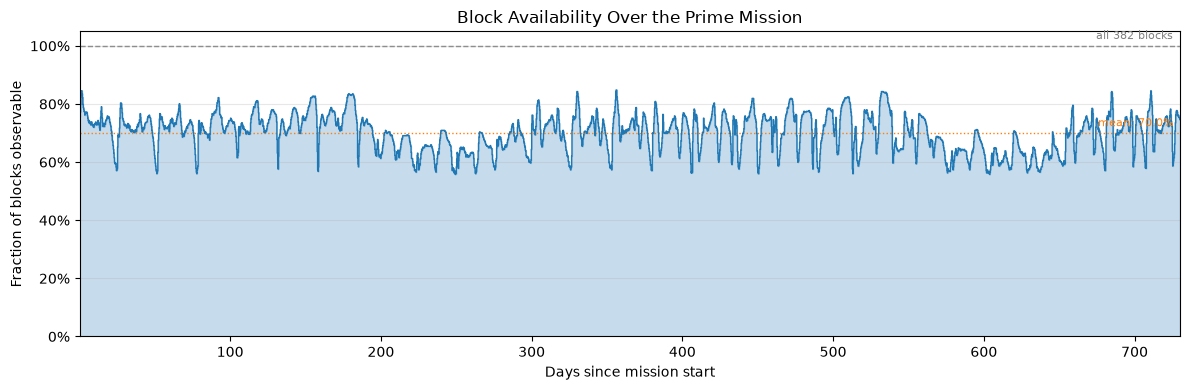

In [67]:
# ======================================== #
# Diagnostic Plot: Block Availability      #
# ======================================== #
# What fraction of blocks are simultaneously observable at each downlink slot across the mission
# -- a supply-side check that enough of the sky is visible to keep the schedule fed, ahead of the
# (much more expensive) matching step below that decides which blocks actually get used.
AVAILABLE_BLOCKS = np.sum(OBSERVABILITY_GRID, axis=0)
AVAILABLE_BLOCK_FRACTION = AVAILABLE_BLOCKS / len(BLOCKS)
_days_since_start = (ALLOCATED_BLOCK_TIMES - MISSION_START_TIME).to_value(u.day)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(
    _days_since_start,
    AVAILABLE_BLOCK_FRACTION,
    step="mid",
    color="tab:blue",
    alpha=0.25,
)
ax.plot(
    _days_since_start,
    AVAILABLE_BLOCK_FRACTION,
    drawstyle="steps-mid",
    color="tab:blue",
    lw=1,
)

ax.axhline(1, color="gray", ls="--", lw=1, zorder=1)
ax.annotate(
    f"all {len(BLOCKS)} blocks",
    xy=(1, 1),
    xycoords=("axes fraction", "data"),
    xytext=(-5, 3),
    textcoords="offset points",
    ha="right",
    va="bottom",
    color="gray",
    fontsize=8,
)

_mean_fraction = AVAILABLE_BLOCK_FRACTION.mean()
ax.axhline(_mean_fraction, color="tab:orange", ls=":", lw=1, zorder=1)
ax.annotate(
    f"mean: {_mean_fraction:.1%}",
    xy=(1, _mean_fraction),
    xycoords=("axes fraction", "data"),
    xytext=(-5, 3),
    textcoords="offset points",
    ha="right",
    va="bottom",
    color="tab:orange",
    fontsize=8,
)

ax.set_xlim(_days_since_start.min(), _days_since_start.max())
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Days since mission start")
ax.set_ylabel("Fraction of blocks observable")
ax.set_title("Block Availability Over the Prime Mission")
ax.grid(axis="y", alpha=0.3, zorder=0)
fig.tight_layout()

if SAVE_BLOCK_AVAILABILITY_PLOT:
    fig.savefig(
        OUTPUT_PATH / "block_availability.pdf",
        dpi=300,
        metadata={"CreationDate": None},
    )

## Determine Weights

Observability is a hard constraint -- it says whether a `(block, slot)` pairing is legal at all
-- but among the legal pairings, some are still better than others, because UVEX's Galactic and
zodiacal background varies with pointing and time. To capture that preference, we estimate, for
every field and slot, the FUV exposure time needed to reach `SNR_TARGET` for a reference source
under `mission.detector`'s modeled sky background, then sum those exposure times across each
block to get a single per-block, per-slot cost. Lower cost (less background-limited exposure time
needed) is preferred by the matching step below. This weighting affects only *which* legal slot a
block is placed in, not whether it is legal in the first place.

In [68]:
# ========================================= #
# Compute the Exposure-Time Weight Grid     #
# ========================================= #
with observing(
    ALLOCATED_BLOCK_OBSERVER_LOCATIONS[np.newaxis, :],
    GRID_FIELDS["TARGET_COORD"][:, np.newaxis],
    ALLOCATED_BLOCK_TIMES[np.newaxis, :],
):
    _exptime = mission.detector.get_exptime(
        SNR_TARGET,
        synphot.SourceSpectrum(synphot.ConstFlux1D, amplitude=24.5 * u.ABmag),
        "FUV",
    ).to_value(u.s)

EXPOSURE_WEIGHT_GRID = np.asarray(
    [np.sum(_exptime[BLOCK_IDS == i, :], axis=0) for i in range(BLOCK_IDS.max() + 1)]
)
EXPOSURE_WEIGHT_GRID = np.clip(EXPOSURE_WEIGHT_GRID, 0, 86400)

## Optimize

With observability and cost both in hand, block-to-slot assignment reduces to a weighted
bipartite matching. Each block contributes one node per remaining expected visit; each downlink
slot contributes one node. For every `(block, slot)` pair where the block is observable, add an
edge weighted by `EXPOSURE_WEIGHT_GRID`. The minimum-weight full matching then assigns each slot
to the block visit that needs it least expensively, while respecting each block's total visit
budget -- this is the global optimization referred to in the introduction at the top of this
notebook.

In [69]:
# ========================================= #
# Perform the Weighted Bipartite Matching   #
# ========================================= #
MATCHING_GRAPH = nx.Graph()
MATCHING_GRAPH.add_weighted_edges_from(
    ((i, visit), j, EXPOSURE_WEIGHT_GRID[i, j])
    for i, j in zip(*np.nonzero(OBSERVABILITY_GRID))
    for visit in range(int(BLOCK_VISIT_MULTIPLICITY[i]))
)

MATCHING = nx.bipartite.minimum_weight_full_matching(
    MATCHING_GRAPH, np.arange(OBSERVABILITY_GRID.shape[1])
)

MATCHING_I, MATCHING_J = np.transpose(
    [(MATCHING[j][0], j) for j in range(OBSERVABILITY_GRID.shape[1]) if j in MATCHING]
)

The matching above operates at the level of blocks, but the sequencing step that follows needs
individual fields. `TARGETS` reformats `FIELDS` into the schema of `DOWNLINK_TABLE` (`action` and
`duration` columns) so that a block's targets can be stacked directly with its downlink pointing
when we solve the TSP below.

In [70]:
# ========================================= #
# Construct the Observation Target List     #
# ========================================= #
TARGETS = QTable(
    {
        "field_id": GRID_FIELDS["FIELD_ID"],
        "block_id": GRID_FIELDS["BLOCK_ID"],
        "target_coord": SkyCoord(
            GRID_FIELDS["TARGET_COORD"].ra,
            GRID_FIELDS["TARGET_COORD"].dec,
            representation_type=UnitSphericalRepresentation,
        ),
    }
)
TARGETS["action"] = "observe"
TARGETS["duration"] = DWELL_DURATION
TARGETS

field_id,block_id,target_coord,action,duration
,,"deg,deg",,s
int64,int64,SkyCoord,str7,float64
0,107,"180.0,58.282525588538995",observe,900.0
1,84,"0.0,58.282525588538995",observe,900.0
2,296,"180.0,-58.282525588538995",observe,900.0
3,234,"0.0,-58.282525588538995",observe,900.0
4,165,"90.0,31.717474411461005",observe,900.0
5,174,"90.0,-31.717474411461005",observe,900.0
6,208,"270.0,31.717474411461005",observe,900.0
7,197,"270.0,-31.717474411461005",observe,900.0


## Sequence Each Block via TSP

For every matched (block, slot) pair, interleave the block's targets with the downlink pointing
that starts it and solve a TSP for the slew-minimizing observing order, then stitch the per-block
plans together (in slot order) into the full mission timeline.

Each block's plan keeps every one of its dwells; when two block-visits are stitched back to back,
only the trailing row of the earlier one is dropped, since the next block's downlink pointing
immediately supersedes it.

In [71]:
# ========================================= #

# Sequence and Stitch the Mission Timeline  #
# ========================================= #
def plan_block(downlink, targets):
    """
    Sequence one scheduling block: interleave its targets with the downlink pointing and solve
    the TSP for the slew order that minimizes total slew time.

    Parameters
    ----------
    downlink : astropy.table.QTable
        A single-row table for the downlink pointing that starts the block.
    targets : astropy.table.QTable
        The block's observation targets.

    Returns
    -------
    astropy.table.QTable
        The block's plan: downlink and observations interleaved with the slews between them, in
        chronological order.
    """
    slew_targets = vstack((downlink, targets))
    slew_targets["roll"] = nominal_roll(
        slew_targets["observer_location"][0],
        slew_targets["target_coord"],
        slew_targets["start_time"][0],
    )

    slew_time = mission.slew.time(
        slew_targets["target_coord"][:, np.newaxis],
        slew_targets["target_coord"][np.newaxis, :],
        slew_targets["roll"][:, np.newaxis],
        slew_targets["roll"][np.newaxis, :],
    )
    # A field-mode block's targets include several duplicate rows for the same field (see
    # GRID_FIELDS above) -- there is no real slew between two dwells on an identical
    # coordinate, so zero those out before solving the TSP. Without this, solve_tsp would pay
    # (and then optimize away) a spurious "slew" between two back-to-back dwells on the same
    # field.
    slew_time[
        slew_targets["target_coord"][:, np.newaxis]
        == slew_targets["target_coord"][np.newaxis, :]
    ] = 0 * u.s
    # timelimit caps the worst case (e.g. the tightly-clustered MC block) at a bounded, still-good
    # tour instead of an unbounded search to prove optimality -- see PLAN_BLOCK_TSP_TIMELIMIT above.
    seq, _ = solve_tsp(
        slew_time.to_value(u.s), verbose=False, timelimit=PLAN_BLOCK_TSP_TIMELIMIT
    )
    assert seq[0] == 0

    # Find optimal slew path.
    slews = QTable({"duration": slew_time[seq[:-1], seq[1:]]})
    slews["action"] = "slew"

    # Interleave slews with observations.
    slew_targets = slew_targets[seq]
    slew_targets["i"] = np.arange(len(slew_targets))
    slews["i"] = np.arange(len(slews)) + 0.5
    plan = vstack((slew_targets, slews))
    plan.sort("i")
    del plan["i"]

    # Fill in observation times, observer locations.
    plan["start_time"][1:] = plan["start_time"][0] + np.cumsum(plan["duration"][:-1])
    plan["observer_location"] = mission.observer_location(plan["start_time"])

    return plan


PLAN = vstack(
    [
        plan_block(DOWNLINK_TABLE[j : j + 1], TARGETS[BLOCK_IDS == i])[
            : (-1 if n < len(MATCHING_J) - 1 else None)
        ]
        for n, (i, j) in enumerate(zip(tqdm(MATCHING_I), MATCHING_J))
    ]
)
PLAN

100%|██████████| 1821/1821 [26:47<00:00,  1.13it/s]    


start_time,target_coord,roll,"observer_location [x, y, z]",action,duration,field_id,block_id
,"deg,deg",deg,km,,s,,
Time,SkyCoord,float64,"(float64, float64, float64)",str8,float64,int64,int64
2030-01-01 00:00:00.000,"174.5234213209899,34.128505977322746",-78.65241364528512,"(-81738.11118027725, 139031.08830193704, 46928.760287802346)",downlink,1800.0,--,--
2030-01-01 00:30:00.000,"———,———",———,"(-59873.49553080485, 148038.69777579428, 47965.94335290025)",slew,247.56171254706877,--,--
2030-01-01 00:34:07.562,"141.86121394629728,2.820204884164472",-59.25147883072057,"(-56783.660415428865, 149016.7438995937, 48107.542573381535)",observe,900.0,555,47
2030-01-01 00:49:07.562,"———,———",———,"(-45426.055478067436, 152030.51791060367, 48620.13175645414)",slew,109.40074884208997,--,--
2030-01-01 00:50:56.962,"139.37946092292034,1.6482077980116383",-56.92370937601021,"(-44034.1630215027, 152338.5734882652, 48682.203855298154)",observe,900.0,559,47
2030-01-01 01:05:56.962,"———,———",———,"(-32516.01577879973, 154390.07694346478, 49190.8737812765)",slew,113.89224148041322,--,--
2030-01-01 01:07:50.855,"138.9811528247357,-1.5103980713443668",-53.949882595646855,"(-31051.750703686255, 154588.16227243142, 49254.991164963045)",observe,900.0,560,47
2030-01-01 01:22:50.855,"———,———",———,"(-19453.77898494161, 155666.1641343334, 49759.62830668922)",slew,112.67249005400518,--,--


## Finalize and Validate the Timeline

`PLAN` is now a complete, chronologically stitched timeline, but it was assembled by pasting
together thousands of independently-solved per-block plans, so it is worth checking that the
stitching didn't introduce any inconsistencies before writing it to disk. The next few cells
verify that no two consecutive actions overlap in time (a basic self-consistency check on the
per-block start times computed above), record the total time spent in each action type as
metadata for quick mission-level accounting, and compute the slew angle preceding each action for
later analysis and plotting.

In [72]:
# ========================================= #
# Sanity Check: No Overlapping Actions      #
# ========================================= #
_end_time = PLAN["start_time"] + PLAN["duration"]
_min_gap = ((PLAN["start_time"][1:] - _end_time[:-1]).to(u.s)).min()

print("-----------------------------------------------------------------")
print(f"Minimum gap between consecutive actions: {_min_gap:.2e}")
print("-----------------------------------------------------------------")
assert _min_gap >= -1e-3 * u.s

-----------------------------------------------------------------
Minimum gap between consecutive actions: -1.92e-11 s
-----------------------------------------------------------------


In [73]:
# ========================================= #
# Add Total Time Metadata                   #
# ========================================= #
_total_time_by_action = (
    PLAN["action", "duration"].group_by("action").groups.aggregate(np.sum)
)
PLAN.meta["total_time"] = {
    str(row["action"]): row["duration"] for row in _total_time_by_action
}

_end_time = PLAN["start_time"] + PLAN["duration"]
_down_time = (PLAN["start_time"][1:] - _end_time[:-1]).to(u.s)
PLAN.meta["total_time"]["slack"] = np.maximum(_down_time, 0 * u.s).sum()

In [74]:
# ========================================= #
# Add Slew Angles                           #
# ========================================= #
_args = [
    PLAN["target_coord"][:-2],
    PLAN["target_coord"][2:],
    PLAN["roll"][:-2],
    PLAN["roll"][2:],
]
PLAN["slew_angle"] = Masked(
    np.pad(EigenAxisSlew.separation(*_args), 1, constant_values=np.nan),
    np.pad(combine_masks([arg.mask for arg in _args]), 1, constant_values=True),
)

## Save Schedule to Disk

Write the completed mission timeline -- downlinks, slews, and observations in chronological order
-- to ``initial-survey.ecsv``.

In [75]:
# ========================================= #
# Save the Schedule to Disk                 #
# ========================================= #
PLAN[
    "start_time",
    "duration",
    "observer_location",
    "action",
    "target_coord",
    "roll",
    "field_id",
    "block_id",
    "slew_angle",
].write(OUTPUT_PATH / "initial-survey.ecsv", overwrite=True)

## Animation

Render an (optional) animation of the survey schedule: for each field, the number of field-visits
its block has delivered so far, with the named survey region boundaries and a date/day counter
overlaid. Controlled by ``SAVE_SCHEDULE_ANIMATION`` -- off by default, since animating the full
``PRIME_MISSION_DURATION`` timeline is expensive.

203it [00:35,  5.72it/s]                         


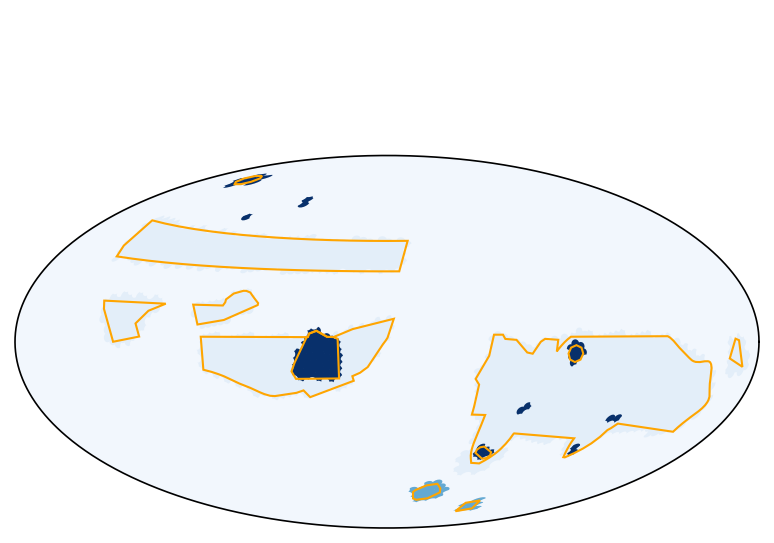

In [76]:
%%skipif not SAVE_SCHEDULE_ANIMATION
# ========================================= #
# Animate the Survey Schedule               #
# ========================================= #
# Render an all-sky animation of the mission timeline: one patch per field, colored (Blues) by
# how many field-visits/dwells that field's block has delivered so far, plus the survey region
# boundaries (orange) and a running date/day counter.
_animation_total_duration = PLAN["start_time"][-1] + PLAN["duration"][-1] - PLAN["start_time"][0]
_animation_frame_times = PLAN["start_time"][0] + np.linspace(0, 1, ANIMATION_N_FRAMES) * _animation_total_duration

# Each matched block-visit actually happens at the start of its assigned downlink slot
# (MATCHING_I/MATCHING_J from the Optimize section above), independent of the TSP ordering of
# fields within the block.
_visit_block_ids = MATCHING_I
_visit_start_times = DOWNLINK_TABLE["start_time"][MATCHING_J]
_n_blocks = BLOCK_IDS.max() + 1

# BLOCKS["DWELLS_PER_VISIT"] converts a raw block-visit count into a field-visit/dwell count: 1
# for an ordinary (spatially-tiled) block, MAX_DWELLS_PER_BLOCK_NO_SLEW for a field-mode block
# like LMLZ Deep (see "Field-Mode Blocks" in skyblocks.ipynb) -- so a field-mode block-visit is
# worth many more dwells than an ordinary one. Multiplying by it here (rather than normalizing to
# a 0-1 completion fraction) keeps the raw, un-normalized field-visit counts this animation has
# always shown, while still being correct about what one block-visit is actually worth. This is
# exactly what BLOCKS["FIELD_VISITS"] already is -- see skyblocks.ipynb's per-block schema note.
_dwells_per_block_visit = BLOCKS["DWELLS_PER_VISIT"]


def _visits_so_far(time):
    _counts = np.bincount(_visit_block_ids[_visit_start_times < time], minlength=_n_blocks)
    return _counts * _dwells_per_block_visit


_shift = 4 * u.hourangle
_center = SkyCoord(12 * u.hourangle - _shift, 0 * u.deg)

fig = plt.figure(dpi=ANIMATION_DPI)
ax = fig.add_subplot(projection="astro aitoff", center=_center)
for key in ["ra", "dec"]:
    ax.coords[key].set_ticklabel_visible(False)
    ax.coords[key].set_ticks_visible(False)
_transform = ax.get_transform("world")

# Build one patch per field (at a fixed position) up front; per frame we only ever update the
# color array, never the geometry.
_field_polygons = []
_field_patch_block_ids = []
for block_id, region in zip(FIELDS["BLOCK_ID"], fov.footprint(INSCRIBED_CIRCLE_FOV, FIELDS["TARGET_COORD"])):
    vertices = circle_to_polygon(region, 16).vertices
    for cut_vertices in plot.cut_prime_meridian(
        np.column_stack(((vertices.ra + _shift).to_value(u.rad), vertices.dec.rad))
    ):
        cut_vertices[:, 0] -= _shift.to_value(u.rad)
        _field_polygons.append(plt.Polygon(np.rad2deg(cut_vertices), closed=True))
        _field_patch_block_ids.append(block_id)
_field_patch_block_ids = np.asarray(_field_patch_block_ids)

_field_patches = PatchCollection(_field_polygons, transform=_transform, cmap="Blues", edgecolor="none")
_field_patches.set_clim(0, BLOCKS["FIELD_VISITS"].max())
_field_patches.set_array(np.zeros(len(_field_polygons)))
ax.add_collection(_field_patches)

# Survey region boundaries (LMLZ Wide/Deep, MC) -- drawn once, the same way skyblocks.ipynb draws
# them on its own sky plots: circles approximated as polygons (so they render correctly under
# this projection), point regions skipped (nothing to outline), everything else plotted via
# region.to_pixel(ax.wcs) directly (no manual prime-meridian cutting needed for this method).
_animation_regions = [
    region
    for _region_file in ANIMATION_REGION_FILES
    for region in Regions.read(str(_region_file))
    if not isinstance(region, PointSkyRegion)
]
_animation_plot_regions = [
    circle_to_polygon(region, 8) if isinstance(region, CircleSkyRegion) else region
    for region in _animation_regions
]
for region in _animation_plot_regions:
    ax.add_patch(
        region.to_pixel(ax.wcs).as_artist(edgecolor="orange", linewidth=1, facecolor="none")
    )

_day_text = fig.text(0.5, 0.95, "", ha="center", va="top", fontsize="x-large", fontweight="bold")

with tqdm(total=len(_animation_frame_times)) as progress:

    def animate(i):
        time = _animation_frame_times[i]
        _field_patches.set_array(_visits_so_far(time)[_field_patch_block_ids])
        _day_number = (time - _animation_frame_times[0]).to_value(u.day)
        _day_text.set_text(f"{time.iso[:10]}  (Day {_day_number:.1f})")
        progress.update()
        return [_field_patches, _day_text]

    FuncAnimation(
        fig, animate, np.arange(len(_animation_frame_times)), blit=True, interval=ANIMATION_INTERVAL
    ).save(OUTPUT_PATH / "initial-survey.mp4")